In [ ]:
# E3 — Forward-modelling the quenched-burst window

**Hypothesis**: the low-Dn4000 clump (Dn4000 1.0–1.4, Hδ_A 0–2 Å, weak emission) is the *recently-quenched burst* phase — SF ended 10–50 Myr ago (post-nebular, pre-A-star; Balmer-EW ingredient verified in González-Delgado+1999, papers/astro-ph_9907116).

**Test**: select the prior's own quenched-burst draws (SFR₁₋₁₀ < ⅓·SFR₁₀₋₅₇ and SFR₁₀₋₅₇ > 3·SFR₍>57₎), push them through the SAME mock pipeline (Cue predict, DESI grid + resolution matrix), measure Dn4000/Hδ_A with the SAME band-integration code, and overlay on the index plane against the full mock prior predictive and the outlier clump.

**Decision rule**: quenched-burst draws land on/near the clump → mechanism demonstrated and the deficit becomes a quantified prior-thinness statement. They land on the mock ridge instead → mechanism dead; back to partial-dilution/other.

**Controls in the experiment**: a random (non-selected) draw subset run through the identical path — must land on the ridge, else the pipeline (not the mechanism) is broken.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy, sys

from hubersed.prospector.utils import make_stochastic_agebins, universe_age_gyr
from hubersed.distributions import sample_truncated_normal, sample_log_uniform, sample_uniform
from prospect.models.hyperparam_transforms import extended_regulator_model_kernel_paramlist

sys.path.insert(0, "../bin/model_seds")
import make_model_seds as MMS  # template builder + DESI grid + resolution matrix
from prospect.models.sedmodel import HyperSpecModel

rng = np.random.default_rng(11)
NPOOL = 30000  # joint prior draws to search for the rare corner

/Users/ng27753/Astronomy_Research/hubersed/.venv/lib/python3.13/site-packages/prospect/sources/fake_fsps.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
# joint prior draws — same ranges as get_stochastic_priors.py (wide, Cue)
z = sample_uniform(0.01, 0.6, size=NPOOL, rng=rng)
t_h = universe_age_gyr(z)
draws = dict(
    z=z,
    logmass=sample_uniform(7, 12, size=NPOOL, rng=rng),
    logzsol=sample_uniform(-2.5, 0.5, size=NPOOL, rng=rng),
    sigma_reg=sample_log_uniform(0.1, 5, size=NPOOL, rng=rng),
    tau_eq=sample_uniform(0.01, t_h, size=NPOOL, rng=rng),
    tau_in=sample_uniform(0.01, t_h, size=NPOOL, rng=rng),
    sigma_dyn=sample_log_uniform(0.001, 0.5, size=NPOOL, rng=rng),
    tau_dyn=sample_truncated_normal(0.01, 0.02, 0.005, 0.2, size=NPOOL, rng=rng),
    dust_index=sample_uniform(-2.5, 0.4, size=NPOOL, rng=rng),
    dust2=sample_truncated_normal(0.3, 1.0, 0.0, 4.0, size=NPOOL, rng=rng),
    dust_ratio=sample_truncated_normal(1.0, 0.3, 0.0, 2.0, size=NPOOL, rng=rng),
    gas_logz=sample_uniform(-2.2, 0.5, size=NPOOL, rng=rng),
    gas_logu=sample_uniform(-4, -1, size=NPOOL, rng=rng),
    gas_lognH=sample_uniform(1, 4, size=NPOOL, rng=rng),
    gas_logno=sample_uniform(-1, np.log10(5.4), size=NPOOL, rng=rng),
    gas_logco=sample_uniform(-1, np.log10(5.4), size=NPOOL, rng=rng),
    sigma_smooth=sample_uniform(10, 400, size=NPOOL, rng=rng),
    sigma_gas=sample_uniform(10, 250, size=NPOOL, rng=rng),
    umin=sample_truncated_normal(2.0, 1.0, 0.1, 15.0, size=NPOOL, rng=rng),
    qpah=sample_uniform(0.5, 7.0, size=NPOOL, rng=rng),
    gamma_e=sample_log_uniform(1e-4, 0.1, size=NPOOL, rng=rng),
)
# per-draw SFH from its own PSD params + z-dependent agebins
def sfh_ratios(i, rng):
    ab = make_stochastic_agebins(z=draws["z"][i])
    bc = 10 ** ab.mean(1) / 1e9
    dtau = bc[:, None] - bc[None, :]
    p = [draws[k][i] for k in ("sigma_reg", "tau_eq", "tau_in", "sigma_dyn", "tau_dyn")]
    cov = extended_regulator_model_kernel_paramlist(dtau, p) + 1e-10 * np.eye(len(bc))
    logsfr = rng.multivariate_normal(np.zeros(len(bc)), cov, method="cholesky")
    return ab, logsfr, np.diff(logsfr)[::1]  # ratios = adjacent differences

# classify the SFH shape without generating spectra yet
sel_q, sel_r, cache = [], [], {}
for i in range(NPOOL):
    ab, logsfr, _ = sfh_ratios(i, rng)
    dt = np.diff(10 ** ab, 1).ravel()
    sfr = 10 ** logsfr
    s010 = (sfr[:2] * dt[:2]).sum() / dt[:2].sum()
    s1050 = (sfr[2:4] * dt[2:4]).sum() / dt[2:4].sum()
    s_old = (sfr[4:] * dt[4:]).sum() / dt[4:].sum()
    cache[i] = (ab, logsfr)
    if (s010 / s1050 < 1/3) and (s1050 / s_old > 3):
        sel_q.append(i)
    elif len(sel_r) < 60 and rng.random() < 0.01:
        sel_r.append(i)
print(f"quenched-burst draws: {len(sel_q)}; random reference: {len(sel_r)}")

quenched-burst draws: 108; random reference: 60


In [3]:
# generate spectra through the SAME pipeline as the mock library
MMS._S["nebular"] = "cue"; MMS._S["seed"] = 11
base = MMS.build_base_template("cue")
R_mat = MMS._get_resolution_matrix()
sps = MMS._get_sps("cue")
obs = MMS.make_obs(MMS.DESI_WAV.size)

KEYMAP = {"logmass": "logmass", "logzsol": "logzsol", "dust_index": "dust_index",
          "dust_ratio": "dust_ratio", "dust2": "dust2", "gas_logz": "gas_logz",
          "gas_logu": "gas_logu", "gas_lognH": "gas_lognH", "gas_logno": "gas_logno",
          "gas_logco": "gas_logco", "sigma_reg": "sigma_reg", "tau_eq": "tau_eq",
          "tau_in": "tau_in", "sigma_dyn": "sigma_dyn", "tau_dyn": "tau_dyn",
          "sigma_smooth": "sigma_smooth", "umin": "duste_umin", "qpah": "duste_qpah",
          "gamma_e": "duste_gamma"}

def predict_one(i):
    t = copy.deepcopy(base)
    for k, tk in KEYMAP.items():
        t[tk]["init"] = draws[k][i]
    t["eline_sigma"]["init"] = draws["sigma_gas"][i]
    t["zred"]["init"] = draws["z"][i]
    ab, logsfr = cache[i]
    t["agebins"]["init"] = ab
    t = MMS.adjust_stochastic_params(t)
    t["logsfr_ratios"]["init"] = -np.diff(logsfr)  # ratio_j = log SFR_j - log SFR_j+1
    model = HyperSpecModel(configuration=t)
    preds, _ = model.predict(model.theta, [obs], sps=sps)
    spec = R_mat.dot(preds[0])  # maggies, observed frame, lines included
    elum = np.asarray(model._eline_lum, dtype=float)  # Lsun/Msun formed, attenuated
    ewave = np.asarray(model._eline_wave, dtype=float)
    return spec, elum, ewave

Loading calibrated DESI resolution from resolution matrices...


In [4]:
# index measurement — identical band definitions to measure_indices.py
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
LSUN, JY, C_AA, C_KMS = 3.846e33, 3631e-23, 2.998e18, 2.998e5
DN_B, DN_R = (3850., 3950.), (4000., 4100.)
HD_I, HD_B, HD_R = (4083.5, 4122.25), (4041.6, 4079.75), (4128.5, 4161.0)
LAM = MMS.DESI_WAV
from hubersed.prospector.lsf import desi_resolution
LSF_AA = LAM / (desi_resolution(LAM) * 2.355)

def measure_pair(lam_r, flam):
    fnu = flam * lam_r**2
    bands = []
    for lo, hi in (DN_B, DN_R):
        s = (lam_r >= lo) & (lam_r <= hi)
        if s.sum() < 5: return np.nan, np.nan
        bands.append(fnu[s].mean())
    dn = bands[1] / bands[0]
    pts, lams = [], []
    for lo, hi in (HD_B, HD_R):
        s = (lam_r >= lo) & (lam_r <= hi)
        if s.sum() < 4: return dn, np.nan
        pts.append(flam[s].mean()); lams.append(0.5 * (lo + hi))
    s = (lam_r >= HD_I[0]) & (lam_r <= HD_I[1])
    cont = pts[0] + (pts[1]-pts[0])/(lams[1]-lams[0]) * (lam_r[s]-lams[0])
    return dn, float(np.sum((1 - flam[s]/cont) * np.gradient(lam_r[s])))

def indices_for(i, spec, elum, ewave):
    zp1 = 1 + draws["z"][i]
    lam_r = LAM / zp1
    dl = cosmo.luminosity_distance(draws["z"][i]).to("cm").value
    flam = spec * JY * C_AA / LAM**2
    sel = (ewave > 3800) & (ewave < 4250)
    F = elum[sel] * 10**draws["logmass"][i] * LSUN / (4*np.pi*dl**2)
    for w0r, Fk in zip(ewave[sel], F):
        if Fk <= 0: continue
        w0 = w0r * zp1
        s_aa = np.sqrt((w0*draws["sigma_gas"][i]/C_KMS)**2 + np.interp(w0, LAM, LSF_AA)**2)
        m = np.abs(LAM - w0) < 6*s_aa
        flam[m] -= Fk/(np.sqrt(2*np.pi)*s_aa)*np.exp(-0.5*((LAM[m]-w0)/s_aa)**2)
    ok = (lam_r > 3820) & (lam_r < 4200)
    return measure_pair(lam_r[ok], (flam*zp1)[ok])

res = {}
for lab, idxs in [("quenched", sel_q), ("reference", sel_r)]:
    out = []
    for n, i in enumerate(idxs):
        try:
            spec, elum, ewave = predict_one(i)
            out.append(indices_for(i, spec, elum, ewave))
        except Exception as e:
            out.append((np.nan, np.nan))
        if (n+1) % 20 == 0: print(lab, n+1, "/", len(idxs), flush=True)
    res[lab] = np.array(out)
    v = res[lab]; f = np.isfinite(v).all(1)
    print(lab, "finite:", f.sum(), "Dn4000 med", np.nanmedian(v[f,0]).round(3),
          "HdA med", np.nanmedian(v[f,1]).round(2))

Loading calibrated DESI resolution from resolution matrices...


quenched 20 / 108


quenched 40 / 108


quenched 60 / 108


quenched 80 / 108


...

quenched finite: 108 Dn4000 med 1.25 HdA med 6.26


reference 20 / 60


reference 40 / 60


reference 60 / 60


reference finite: 60 Dn4000 med 1.351 HdA med 5.82


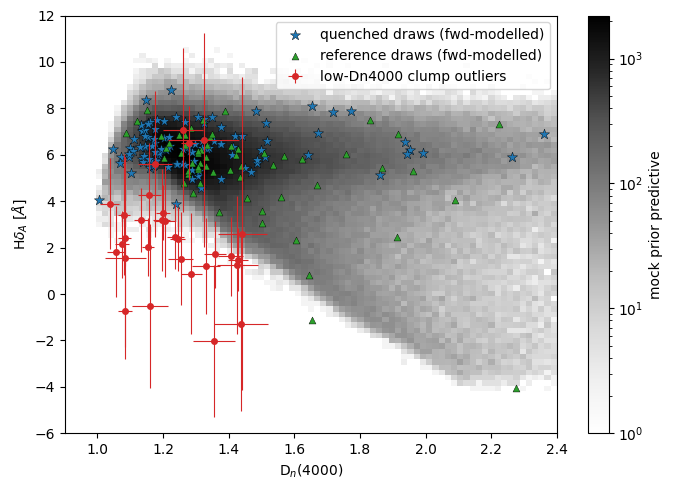

In [5]:
# overlay on the index plane
mi = np.load("../results/mock_indices_wide.npz")
oi = np.load("../results/outlier310_indices.npz", allow_pickle=True)
mok = np.isfinite(mi["dn4000"]) & np.isfinite(mi["hdelta_a"])
clump = ((oi["source_class"] != "emission") & (oi["dn4000"] > 1.0) & (oi["dn4000"] < 1.45))

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(mi["dn4000"][mok], mi["hdelta_a"][mok],
              bins=[np.linspace(0.9, 2.4, 80), np.linspace(-6, 12, 80)],
              cmap="Greys", norm=plt.matplotlib.colors.LogNorm())
ax.errorbar(oi["dn4000"][clump], oi["hdelta_a"][clump], xerr=oi["dn4000_err"][clump],
            yerr=oi["hdelta_a_err"][clump], fmt="o", ms=4, color="C3", lw=0.8,
            label="low-Dn4000 clump outliers")
for lab, c, m in [("quenched", "C0", "*"), ("reference", "C2", "^")]:
    v = res[lab]; f = np.isfinite(v).all(1)
    ax.scatter(v[f, 0], v[f, 1], s=60 if m == "*" else 25, marker=m, color=c,
               edgecolor="k", lw=0.3, label=f"{lab} draws (fwd-modelled)")
ax.set_xlabel(r"D$_n$(4000)"); ax.set_ylabel(r"H$\delta_A$ [$\AA$]")
ax.legend(); plt.colorbar(h[3], ax=ax, label="mock prior predictive")
plt.tight_layout()